# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [3]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
39,-0.001882,0.050680,0.014272,-0.074527,0.002559,0.006202,-0.013948,-0.002592,0.019196,0.003064,90.0
333,0.027178,0.050680,-0.006206,0.028758,-0.016704,-0.001627,-0.058127,0.034309,0.029297,0.032059,164.0
266,-0.052738,0.050680,-0.062252,0.011544,-0.008449,-0.036700,0.122273,-0.076395,-0.086827,0.003064,45.0
304,0.041708,0.050680,-0.038540,0.052858,0.076860,0.116430,-0.039719,0.071210,-0.022517,-0.013504,253.0
142,0.041708,0.050680,0.012117,0.039087,0.054845,0.044406,0.004460,-0.002592,0.045604,-0.001078,235.0
37,-0.009147,-0.044642,0.011039,-0.057313,-0.024960,-0.042963,0.030232,-0.039493,0.017036,-0.005220,276.0
132,0.016281,0.050680,-0.021295,-0.009113,0.034206,0.047850,0.000779,-0.002592,-0.012909,0.023775,107.0
264,0.034443,0.050680,0.028284,-0.033213,-0.045599,-0.009769,-0.050764,-0.002592,-0.059471,-0.021788,145.0
127,0.034443,0.050680,-0.001895,-0.012556,0.038334,0.013717,0.078093,-0.039493,0.004548,-0.096346,109.0
306,0.009016,0.050680,-0.001895,0.021872,-0.038720,-0.024800,-0.006584,-0.039493,-0.039809,-0.013504,44.0


In [4]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [5]:
# 1. Contar valores faltantes
missing_values = data.isnull().sum()
print("Valores faltantes por columna:")
print(missing_values)

Valores faltantes por columna:
age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64


### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [6]:
# 2. Imputación simple (media) para 'bmi'
imputer_simple = SimpleImputer(strategy='mean')
data['bmi'] = imputer_simple.fit_transform(data[['bmi']])
print("Valores faltantes en 'bmi' tras imputación simple:", data['bmi'].isnull().sum())

Valores faltantes en 'bmi' tras imputación simple: 0


### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [7]:
# 3. KNNImputer para 'bmi' y 'bp'
imputer_knn = KNNImputer(n_neighbors=5)
# Imputamos en las columnas originales bmi y bp
data[['bmi', 'bp']] = imputer_knn.fit_transform(data[['bmi', 'bp']])

print("Valores faltantes tras KNNImputer:")
print(data[['bmi', 'bp']].isnull().sum())

Valores faltantes tras KNNImputer:
bmi    0
bp     0
dtype: int64


### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

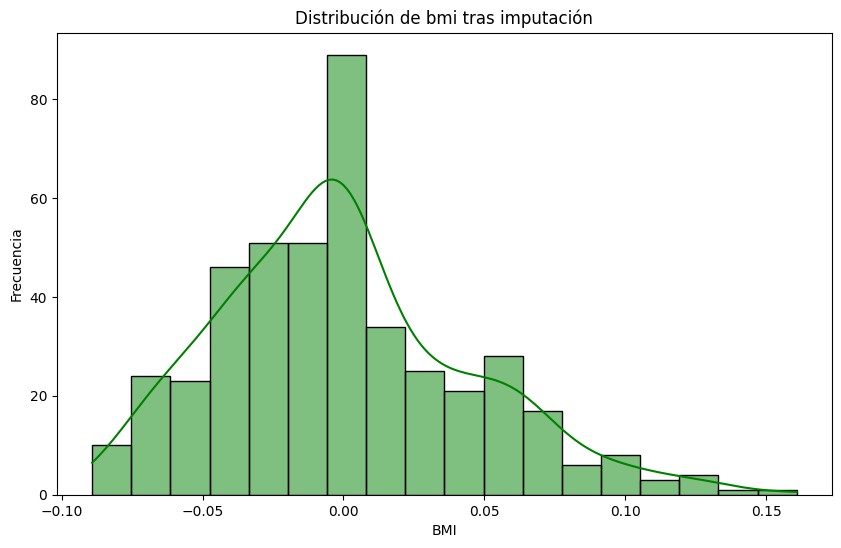

In [8]:
# 4. Histograma comparativo
plt.figure(figsize=(10, 6))
sns.histplot(data['bmi'], kde=True, color='green')
plt.title('Distribución de bmi tras imputación')
plt.xlabel('BMI')
plt.ylabel('Frecuencia')
plt.show()